# Import libraries

In [12]:
import numpy as np # for numerical calculation
import matplotlib.pyplot as plt # for data visualization
import pandas as pd # for dataframe management
import seaborn as sns # for data visualization
from sklearn.model_selection import train_test_split # In order to split up the data for training and those for testing
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # In order to compare the models's performance

In [13]:
df=pd.read_csv("ph-data.csv") # Data importing

In [14]:
df.head()

,blue,green,red,label
0,36,27,231,0
1,36,84,250,1
2,37,164,255,2
3,22,205,255,3
4,38,223,221,4


In [15]:
df

,blue,green,red,label
0,36,27,231,0
1,36,84,250,1
2,37,164,255,2
3,22,205,255,3
4,38,223,221,4
5,29,214,148,5
6,0,181,76,6
7,13,156,0,7
8,92,166,0,8
9,184,191,0,9


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653 entries, 0 to 652
Data columns (total 4 columns):
blue     653 non-null int64
green    653 non-null int64
red      653 non-null int64
label    653 non-null int64
dtypes: int64(4)
memory usage: 20.5 KB


In [17]:
np.shape(df)

(653, 4)

In [18]:
type(df)

pandas.core.frame.DataFrame

In [19]:
df.isnull().sum()

blue     0
green    0
red      0
label    0
dtype: int64

In [20]:
df.duplicated().sum()

206

In [21]:
duplicates = df[df.duplicated()]
print(duplicates)

     blue  green  red  label
35     65    195  132      5
36     73    183   77      6
48     28    237  245      3
49     50    210  180      4
50     65    195  132      5
51     73    183   77      6
57    162     81   90     12
58    157     69   99     13
59    131     44   70     14
90     37     28  238      0
91     36    103  242      1
92     18    197  248      2
93     28    237  245      3
94     50    210  180      4
95     65    195  132      5
97     73    169   51      7
98    107    180   34      8
99    182    185    9      9
100   205    144   70     10
101   164     84   55     11
102   162     81   90     12
103   157     69   99     13
104   131     44   70     14
119    24     23  241      0
120    13    103  244      1
121     0    198  250      2
122     0    239  246      3
123    25    212  180      4
124    55    197  130      5
125    67    185   72      6
..    ...    ...  ...    ...
543   182    185    9      9
544   205    144   70     10
545   165     

In [22]:
df.describe()

,blue,green,red,label
count,653.000000,653.000000,653.000000,653.000000
mean,89.290965,130.094946,120.655436,7.055130
std,74.974850,72.487085,89.581264,4.287951
min,0.000000,0.000000,0.000000,0.000000
25%,22.000000,68.000000,52.000000,3.000000
50%,67.000000,146.000000,90.000000,7.000000
75%,162.000000,189.000000,224.000000,11.000000
max,255.000000,255.000000,255.000000,14.000000


In [23]:
df=df.rename(columns={'green':'G','blue':'B','red':'R','label':'PH'})

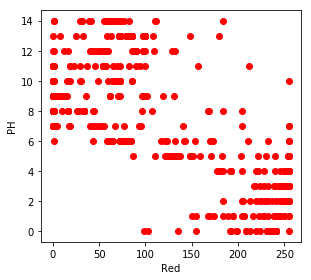

In [24]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(df['R'],df['PH'],color='red')
plt.xlabel('Red'); plt.ylabel('PH')
plt.tight_layout()

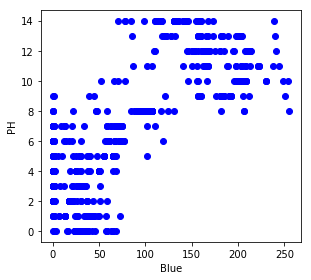

In [25]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(df['B'],df['PH'],color='blue')
plt.xlabel('Blue'); plt.ylabel('PH')
plt.tight_layout()

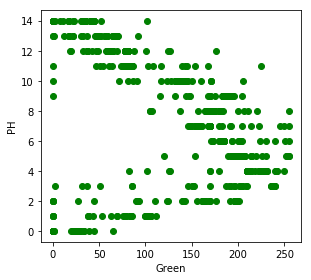

In [26]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(df['G'],df['PH'],color='green')
plt.xlabel('Green'); plt.ylabel('PH')
plt.tight_layout()

In [56]:
X=df[['R' ,'G' , 'B']]
y=df['PH']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [57]:
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

In [58]:
rf_model=RandomForestRegressor(n_estimators=200,random_state=42)
rf_model.fit(X_train,y_train)

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=200, n_jobs=1,
           oob_score=False, random_state=42, verbose=0, warm_start=False)

In [59]:
y_pred_lr=lr_model.predict(X_test)
y_pred_rf=rf_model.predict(X_test)

In [60]:
def evaluate(y_true,y_pred,name):
    mae=mean_absolute_error(y_true,y_pred)
    rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    r2=r2_score(y_true,y_pred)
    print(f"{name}-> MAE: {mae:.3f}, RMSE:{rmse:.3f},R2:{r2:.3f}")

In [61]:
evaluate(y_test,y_pred_lr,"Linear Regression")
evaluate(y_test,y_pred_rf,"Random Forest Regression")

Linear Regression-> MAE: 1.814, RMSE:2.272,R2:0.716
Random Forest Regression-> MAE: 0.513, RMSE:1.200,R2:0.921


In [62]:
def predict_ph(RGB,model='rf'):
    R,G,B=RGB
    X_new=np.array([[R,G,B]])
    if model=='rf':
        return rf_model.predict(X_new)[0]
    else:
        return lr_model.predict(X_new)[0]

In [69]:
print("RGB (0, 0, 255) -> pH:",predict_ph((0,0,255)))

RGB (0, 0, 255) -> pH: 12.68
